In [1]:
import pandas as pd

df_train = pd.read_csv("home-credit-default-risk/application_train.csv")
df_test = pd.read_csv("home-credit-default-risk/application_test.csv")

# 先從 df_train 移除 TARGET 欄位
df_train_no_target = df_train.drop(columns=["TARGET"])

# 兩者欄位相同後再合併
df_all = pd.concat([df_train_no_target, df_test], axis=0, ignore_index=True)

df_all.shape

(356255, 121)

In [2]:
df_all.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


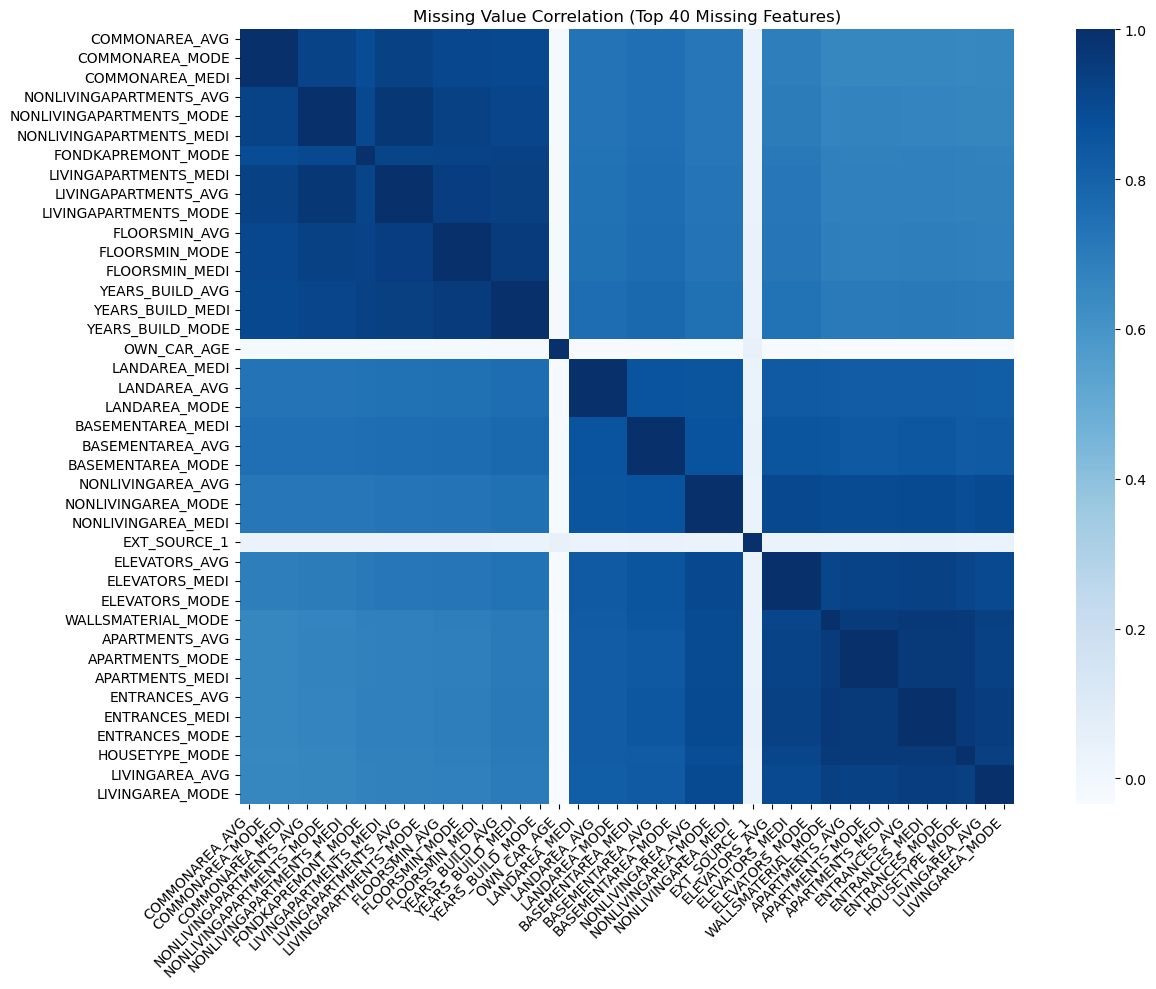

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 計算缺失率
missing_rate = df_all.isnull().mean().sort_values(ascending=False)

# 取缺失率前 20 名
top_cols = missing_rate.head(40).index

# 產生缺失指標
missing_indicators = df_all[top_cols].isnull().astype(int)

# 畫圖
plt.figure(figsize=(14, 10))
sns.heatmap(
    missing_indicators.corr(),
    cmap="Blues",
    cbar=True,
    square=True,
    xticklabels=True,
    yticklabels=True
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Missing Value Correlation (Top 40 Missing Features)")
plt.tight_layout()
plt.show()


In [16]:
combined_data = pd.read_csv("combined.csv")

In [17]:
import pandas as pd

df = combined_data
df_result = df.copy()
threshold = 0.01

for col in df.columns:
    value_counts = df[col].value_counts(normalize=True)
    valid_categories = value_counts[value_counts >= threshold].index
    total_categories = len(value_counts)

    # 所有欄位都檢查二元比例過低的情況
    if total_categories == 2 and len(valid_categories) < 2:
        df_result = df_result.drop(columns=[col])
        continue

    if df[col].dtype == 'object':
        if len(valid_categories) > 0:
            dummies = pd.get_dummies(df[col], dummy_na=False)
            valid_existing = [c for c in valid_categories if c in dummies.columns]
            if valid_existing:
                dummies = dummies[valid_existing]
                dummies.columns = [f"{col}_{c}" for c in dummies.columns]
                df_result = pd.concat([df_result, dummies], axis=1)

        df_result = df_result.drop(columns=[col])

# print(df_result.head())
combined_data = df_result

In [19]:
train_imputed = pd.read_csv('data\inputed_train_test\imputed_train.csv')
test_imputed = pd.read_csv('data\inputed_train_test\imputed_test.csv')

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\i'
C:\Users\487oa\AppData\Local\Temp\ipykernel_20668\1713511289.py:1: SyntaxWarning: invalid escape sequence '\i'
  train_imputed = pd.read_csv('data\inputed_train_test\imputed_train.csv')
C:\Users\487oa\AppData\Local\Temp\ipykernel_20668\1713511289.py:2: SyntaxWarning: invalid escape sequence '\i'
  test_imputed = pd.read_csv('data\inputed_train_test\imputed_test.csv')


In [25]:
# 去掉 TARGET 欄位
train_no_target = train_imputed.drop(columns=["TARGET"])

# 合併 train_no_target 與 test_imputed
df_imputed = pd.concat([train_no_target, test_imputed], axis=0, ignore_index=True)


In [26]:
# 計算每個欄位的缺失比例
missing_ratio = combined_data.isnull().mean()

# 篩選出缺失率 > 0.7 的欄位
cols_over_70 = missing_ratio[missing_ratio > 0.7].index.tolist()

cols_over_70

['MONTHS_BALANCE_mean',
 'AMT_BALANCE_mean',
 'AMT_CREDIT_LIMIT_ACTUAL_mean',
 'AMT_DRAWINGS_CURRENT_sum',
 'AMT_DRAWINGS_POS_CURRENT_sum',
 'AMT_PAYMENT_TOTAL_CURRENT_sum',
 'AMT_RECEIVABLE_PRINCIPAL_mean',
 'AMT_TOTAL_RECEIVABLE_mean',
 'CNT_DRAWINGS_CURRENT_sum',
 'CNT_DRAWINGS_POS_CURRENT_sum',
 'CNT_INSTALMENT_MATURE_CUM_max',
 'SK_DPD_max',
 'SK_DPD_DEF_max',
 'NAME_CONTRACT_STATUS_Active_sum',
 'NAME_CONTRACT_STATUS_Completed_sum',
 'NAME_CONTRACT_STATUS_Other_sum',
 'NAME_CONTRACT_STATUS_Signed_sum',
 'months_with_dpd']

In [28]:
combined_data['AMT_BALANCE_mean']

0                  NaN
1                  NaN
2                  NaN
3              0.00000
4                  NaN
              ...     
356250             NaN
356251             NaN
356252             NaN
356253             NaN
356254    173589.32625
Name: AMT_BALANCE_mean, Length: 356255, dtype: float64

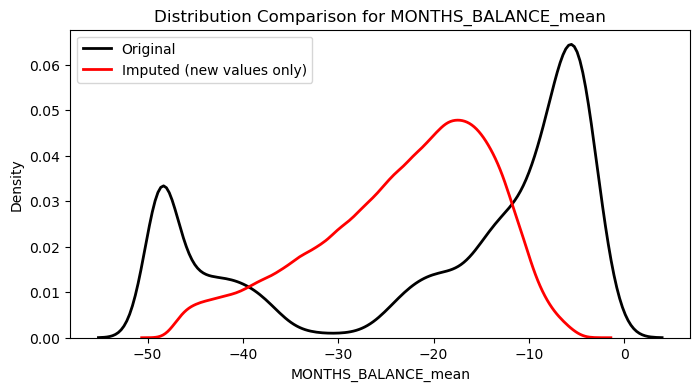

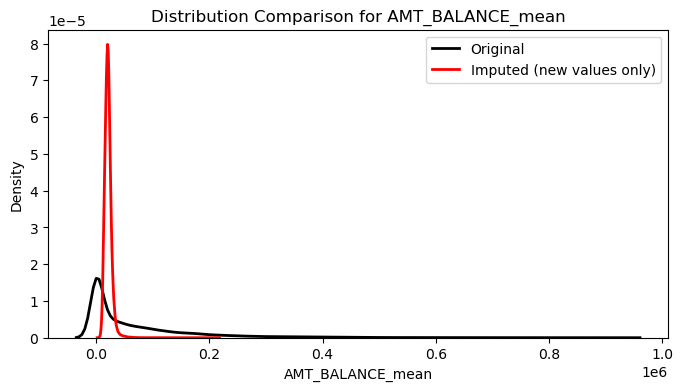

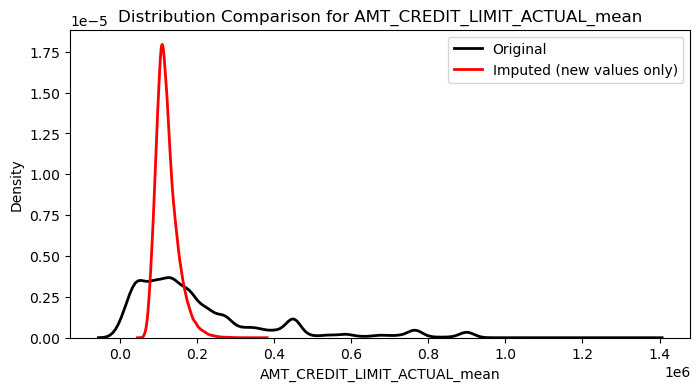

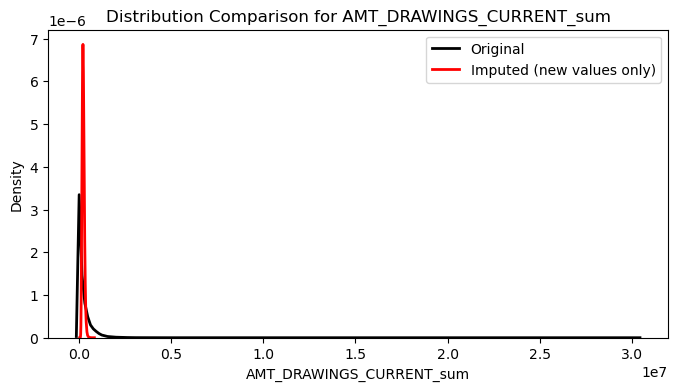

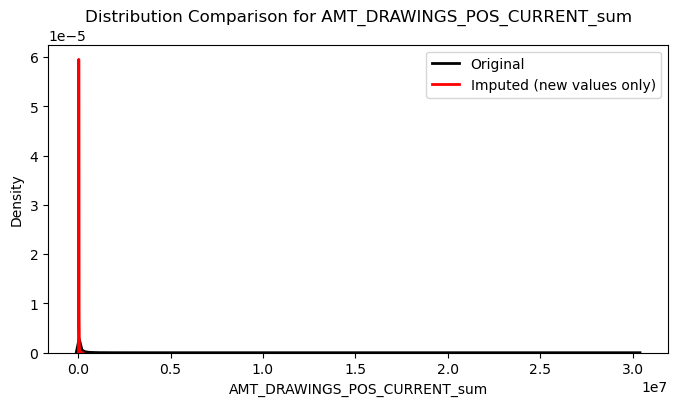

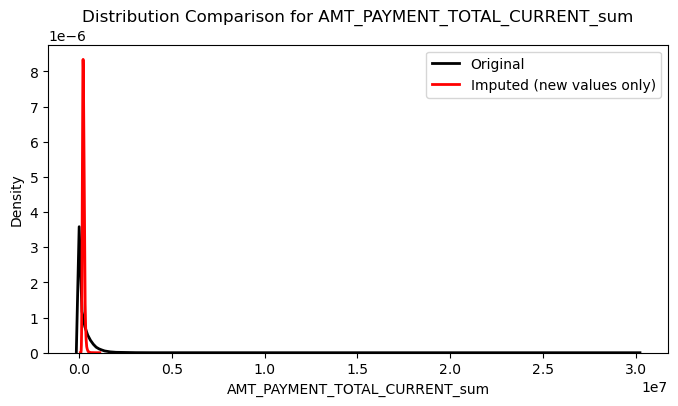

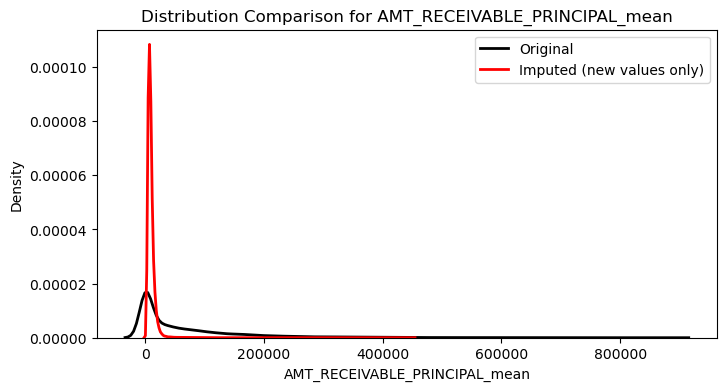

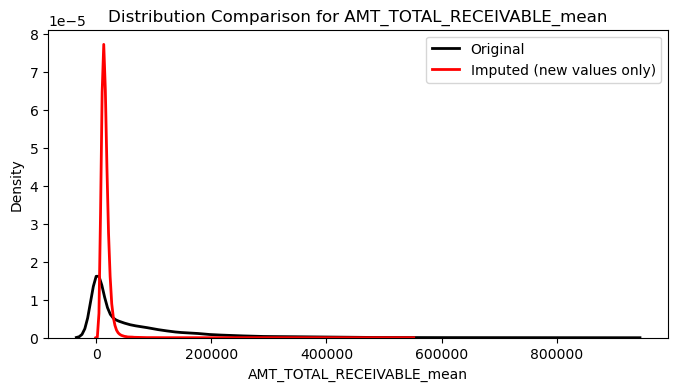

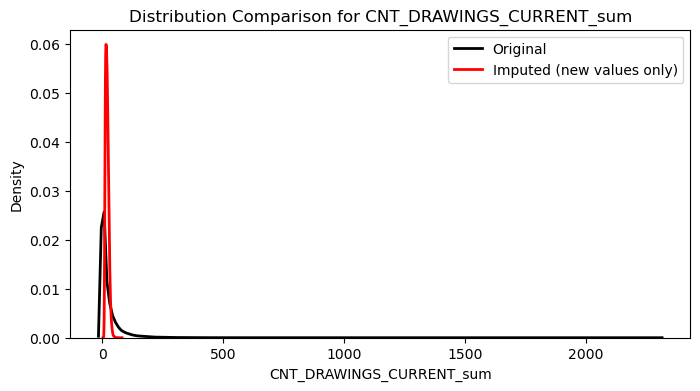

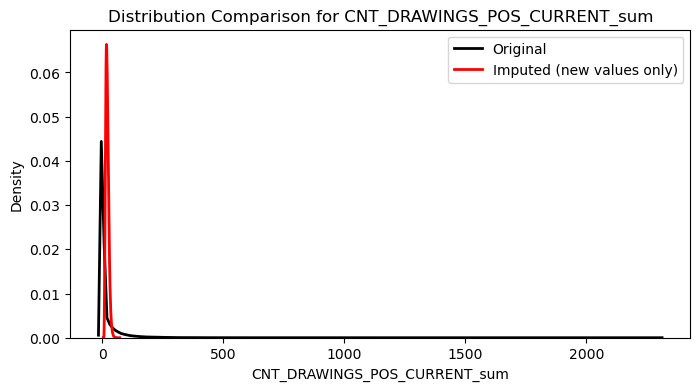

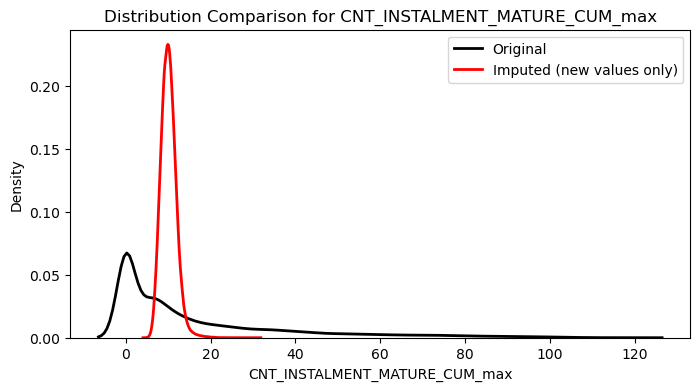

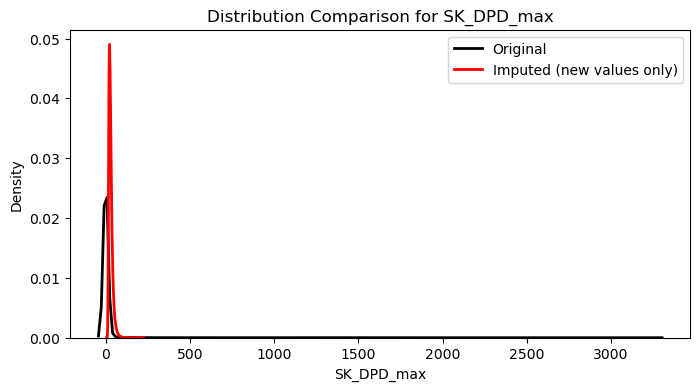

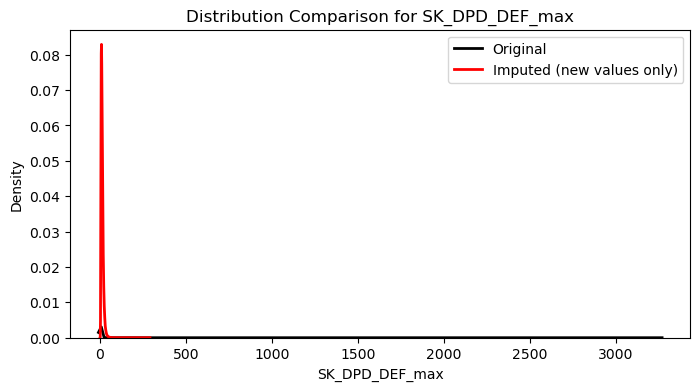

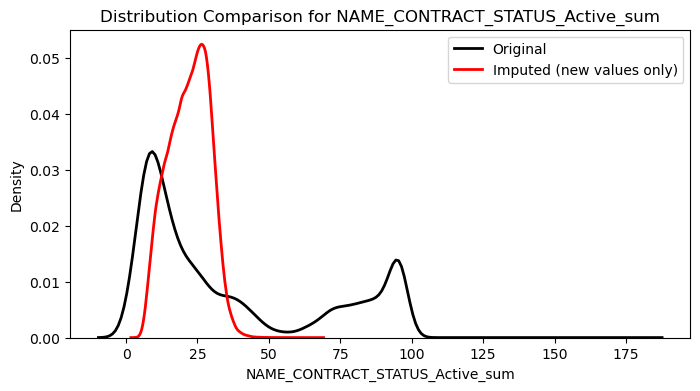

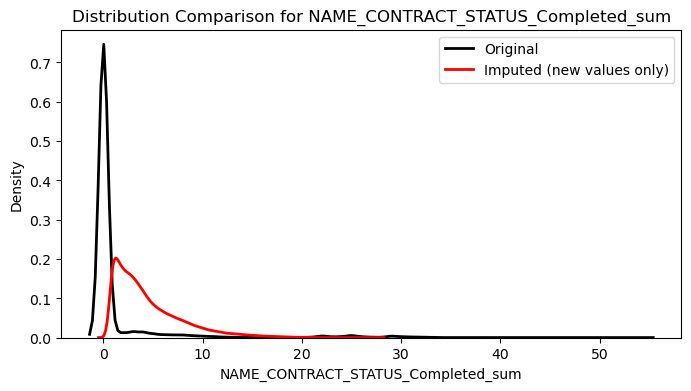

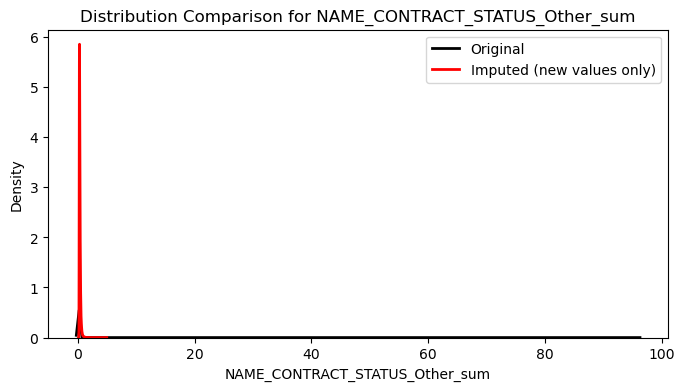

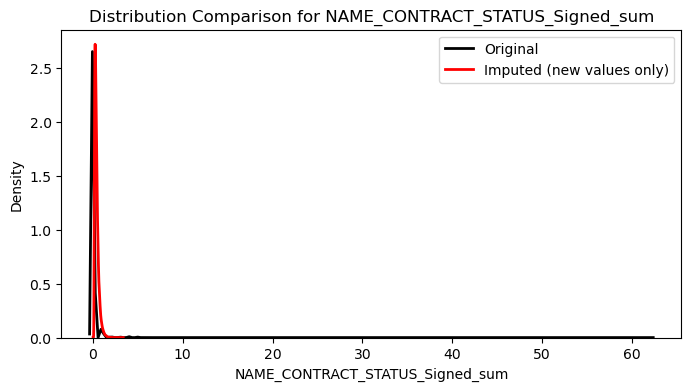

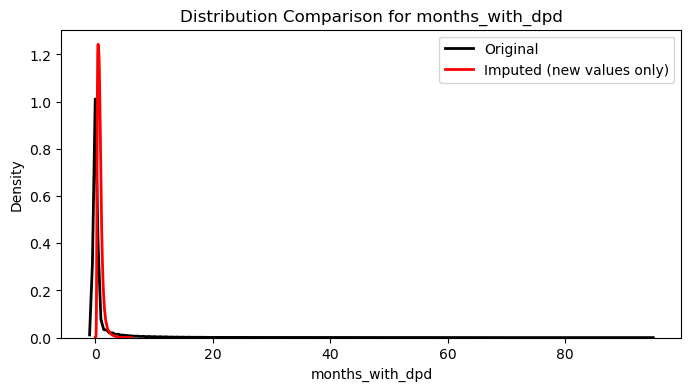

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cols_over_70:
    # 原始非缺失值
    orig_vals = combined_data[col].dropna()

    # 原始缺失 → 填補後的值（你要看的）
    imputed_only_vals = df_imputed[col][combined_data[col].isna()]

    plt.figure(figsize=(8,4))

    # 原始分布（黑色）
    sns.kdeplot(orig_vals, label="Original", color="black", linewidth=2)

    # 填補後的新值（紅色）
    sns.kdeplot(imputed_only_vals, label="Imputed (new values only)", color="red", linewidth=2)

    plt.title(f"Distribution Comparison for {col}")
    plt.legend()
    plt.show()
